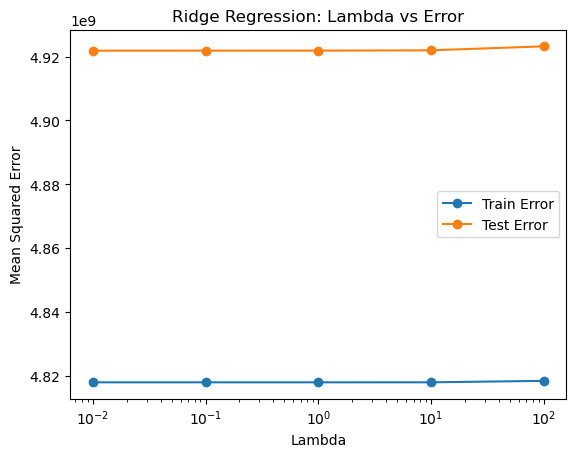


Lasso Coefficients:
[-4.25463361e+04 -4.23356971e+04  1.15510242e+03 -8.44044729e+00
  1.15829862e+02 -3.67587794e+01  4.16412580e+01  4.02932953e+04]
Number of eliminated features: 0


In [3]:
# -----------------------------
# Import Libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error


# -----------------------------
# Ridge Lambda Experiment
# -----------------------------
lambdas = [0.01, 0.1, 1, 10, 100]

train_errors = []
test_errors = []

for l in lambdas:

    model = Ridge(alpha=l)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))


# -----------------------------
# Graph
# -----------------------------
plt.figure()

plt.plot(lambdas, train_errors, marker='o', label="Train Error")
plt.plot(lambdas, test_errors, marker='o', label="Test Error")

plt.xscale("log")

plt.xlabel("Lambda")
plt.ylabel("Mean Squared Error")
plt.title("Ridge Regression: Lambda vs Error")

plt.legend()
plt.show()


# -----------------------------
# Lasso Feature Selection
# -----------------------------
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

coefficients = lasso_model.coef_

print("\nLasso Coefficients:")
print(coefficients)

zero_count = np.sum(coefficients == 0)

print("Number of eliminated features:", zero_count)